# Human Activity Recognition with CNN, SMOTE, and PCA



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization


In [ ]:
# Load Dataset
X_train_raw = np.loadtxt('DataSet/Train/X_train.txt')
y_train_raw = np.loadtxt('DataSet/Train/y_train.txt').astype(int) - 1  # 将标签转换为 0 索引

X_test = np.loadtxt('DataSet/Test/X_test.txt')
y_test = np.loadtxt('DataSet/Test/y_test.txt').astype(int) - 1


In [ ]:
# Balancing the data with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_raw, y_train_raw)


In [ ]:
# Use PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)


In [ ]:
# reshape the dataset
X_train = X_train_pca.reshape((X_train_pca.shape[0], X_train_pca.shape[1], 1))
X_test = X_test_pca.reshape((X_test_pca.shape[0], X_test_pca.shape[1], 1))


In [ ]:
# Construct CNN
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(12, activation='softmax')  #12 actvities
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 98, 64)            256       
                                                                 
 batch_normalization (Batch  (None, 98, 64)            256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 49, 64)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 49, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 47, 128)           24704     
                                                                 
 batch_normalization_1 (Bat  (None, 47, 128)           5

In [ ]:
# Train the model
history = model.fit(X_train, y_train_balanced, epochs=30, batch_size=64, validation_split=0.2)

Epoch 1/30
214/214 [==============================] - 8s 29ms/step - loss: 0.6403 - accuracy: 0.7908 - val_loss: 4.8035 - val_accuracy: 0.0261
Epoch 2/30
214/214 [==============================] - 7s 33ms/step - loss: 0.2110 - accuracy: 0.9238 - val_loss: 3.0568 - val_accuracy: 0.2248
Epoch 3/30
214/214 [==============================] - 7s 30ms/step - loss: 0.1338 - accuracy: 0.9520 - val_loss: 1.1020 - val_accuracy: 0.5261
Epoch 4/30
214/214 [==============================] - 7s 31ms/step - loss: 0.1079 - accuracy: 0.9610 - val_loss: 0.5757 - val_accuracy: 0.7351
Epoch 5/30
214/214 [==============================] - 8s 36ms/step - loss: 0.0922 - accuracy: 0.9661 - val_loss: 0.5446 - val_accuracy: 0.7564
Epoch 6/30
214/214 [==============================] - 6s 26ms/step - loss: 0.0830 - accuracy: 0.9688 - val_loss: 0.3446 - val_accuracy: 0.8609
Epoch 7/30
214/214 [==============================] - 6s 30ms/step - loss: 0.0692 - accuracy: 0.9747 - val_loss: 0.4668 - val_accuracy: 0.8273

99/99 [==============================] - 0s 4ms/step - loss: 0.4223 - accuracy: 0.9187

Test Accuracy: 0.9187
99/99 [==============================] - 1s 5ms/step


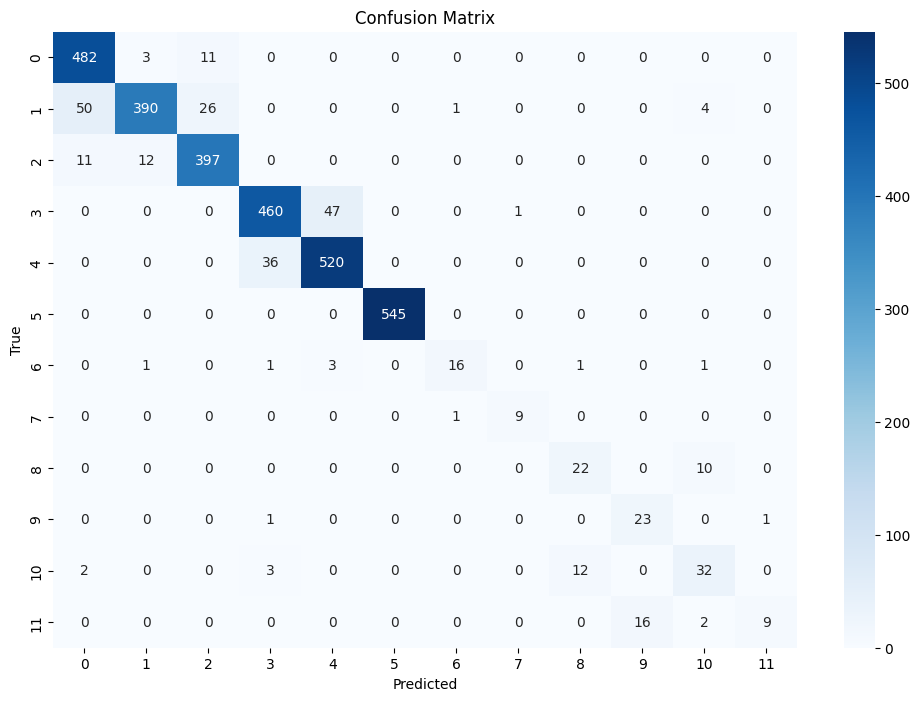


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       496
           1       0.96      0.83      0.89       471
           2       0.91      0.95      0.93       420
           3       0.92      0.91      0.91       508
           4       0.91      0.94      0.92       556
           5       1.00      1.00      1.00       545
           6       0.89      0.70      0.78        23
           7       0.90      0.90      0.90        10
           8       0.63      0.69      0.66        32
           9       0.59      0.92      0.72        25
          10       0.65      0.65      0.65        49
          11       0.90      0.33      0.49        27

    accuracy                           0.92      3162
   macro avg       0.85      0.81      0.81      3162
weighted avg       0.92      0.92      0.92      3162



In [ ]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

# Draw Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))